# Advanced Analytics
## Bluestock Mutual Fund Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
BASE_DIR = Path().resolve().parent

In [3]:
# Load NAV History
nav = pd.read_csv(BASE_DIR / "data/processed/02_nav_history_clean.csv")

# Load Investor Transactions
transactions = pd.read_csv(BASE_DIR / "data/processed/08_investor_transactions_clean.csv")

# Load Fund Recommendations (created by recommender.py)
recommendations = pd.read_csv(BASE_DIR / "data/processed/fund_recommendations.csv")

In [4]:
print("NAV Shape:", nav.shape)
print("Transactions Shape:", transactions.shape)
print("Recommendations Shape:", recommendations.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Recommendations Shape: (40, 4)


In [5]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [7]:
recommendations.head()

,amfi_code,Sharpe_Ratio,CAGR,Recommendation
0,100016,-0.201517,0.025412,High Risk
1,100025,-0.567095,0.042948,High Risk
2,100033,1.093699,0.288994,Recommended
3,101206,1.027213,0.226048,Recommended
4,101207,0.162661,0.076433,High Risk


In [8]:
print(nav.dtypes)

amfi_code      int64
date             str
nav          float64
dtype: object


In [9]:
print(transactions.dtypes)

investor_id               str
transaction_date          str
amfi_code               int64
transaction_type          str
amount_inr              int64
state                     str
city                      str
city_tier                 str
age_group                 str
gender                    str
annual_income_lakh    float64
payment_mode              str
kyc_status                str
dtype: object


In [10]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [11]:
print(nav.isnull().sum())

amfi_code    0
date         0
nav          0
dtype: int64


In [12]:
print(transactions.isnull().sum())

investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64


In [13]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [14]:
returns = nav["daily_return"].dropna()

returns.describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [15]:
var95 = np.percentile(returns, 5)

print("95% Value at Risk (VaR):", round(var95,6))

95% Value at Risk (VaR): -0.016254


In [16]:
var99 = np.percentile(returns, 1)

print("99% Value at Risk (VaR):", round(var99,6))

99% Value at Risk (VaR): -0.025982


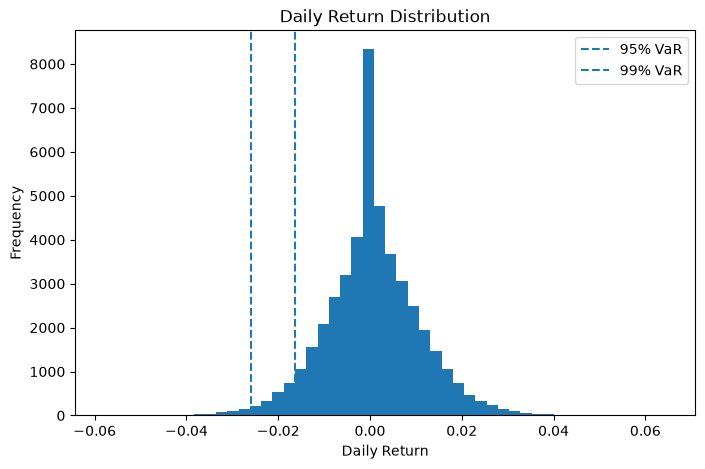

In [17]:
plt.figure(figsize=(8,5))

plt.hist(returns, bins=50)

plt.axvline(var95, linestyle="--", label="95% VaR")

plt.axvline(var99, linestyle="--", label="99% VaR")

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.legend()

plt.show()

## Insights

- The 95% VaR indicates the maximum expected daily loss under normal market conditions with 95% confidence.
- The 99% VaR represents a more extreme downside risk.
- Most daily returns are clustered around zero, while only a small number of observations fall in the tails of the distribution.

In [20]:
rolling_volatility = (
    nav.groupby("amfi_code")["daily_return"]
    .rolling(window=30)
    .std()
    .reset_index(level=0, drop=True)
)

nav["rolling_volatility"] = rolling_volatility

nav.head()

,amfi_code,date,nav,daily_return,rolling_volatility
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


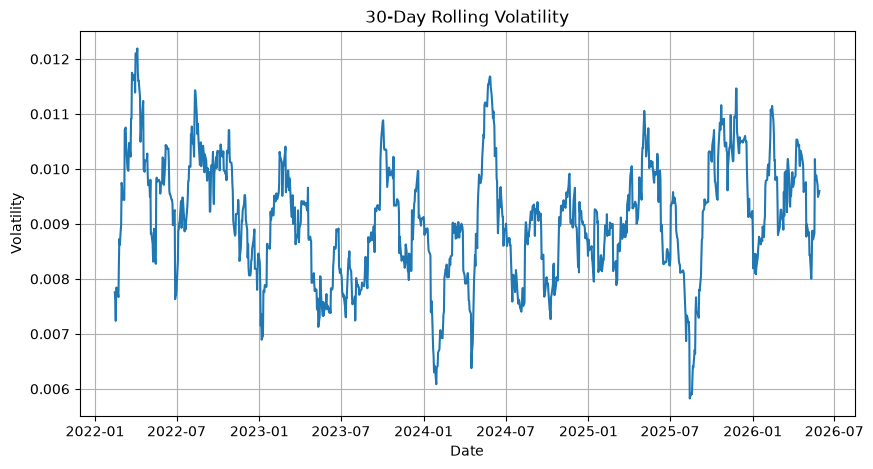

In [21]:
sample_fund = nav["amfi_code"].iloc[0]

sample_data = nav[nav["amfi_code"] == sample_fund]

plt.figure(figsize=(10,5))

plt.plot(sample_data["date"], sample_data["rolling_volatility"])

plt.title("30-Day Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

## Rolling Volatility Insights

- Rolling volatility measures how much fund returns fluctuate over a 30-day period.
- Higher values indicate greater market uncertainty and investment risk.
- Stable periods are represented by lower volatility values.

In [22]:
risk_free_rate = 0.065

rolling_mean = (
    nav.groupby("amfi_code")["daily_return"]
    .rolling(window=30)
    .mean()
    .reset_index(level=0, drop=True)
)

rolling_std = (
    nav.groupby("amfi_code")["daily_return"]
    .rolling(window=30)
    .std()
    .reset_index(level=0, drop=True)
)

nav["rolling_sharpe"] = (
    (rolling_mean * 252 - risk_free_rate)
    / (rolling_std * np.sqrt(252))
)

nav.head()

,amfi_code,date,nav,daily_return,rolling_volatility,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN


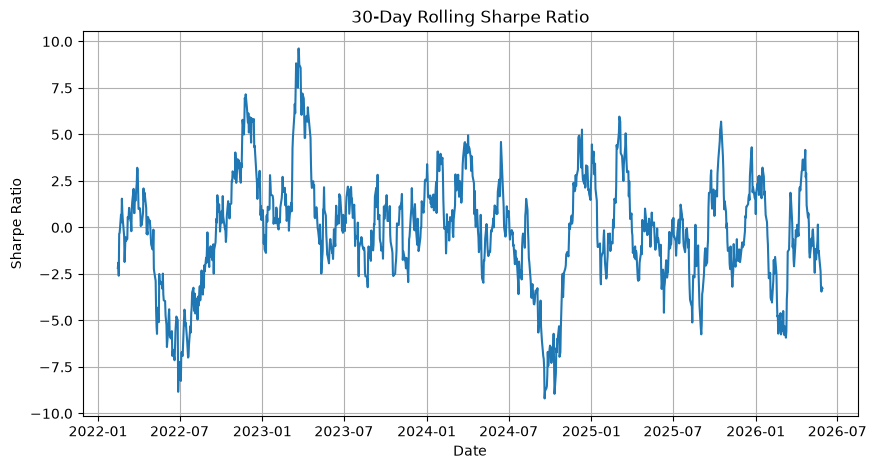

In [23]:
sample_fund = nav["amfi_code"].iloc[0]

sample_data = nav[nav["amfi_code"] == sample_fund]

plt.figure(figsize=(10,5))

plt.plot(sample_data["date"], sample_data["rolling_sharpe"])

plt.title("30-Day Rolling Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.show()

## Rolling Sharpe Ratio Insights

- A higher Sharpe Ratio indicates better risk-adjusted returns.
- Positive values suggest investors are receiving adequate returns for the level of risk taken.
- Lower or negative values indicate weaker performance relative to risk.

## Cohort Analysis Insights

- Investors are grouped according to their first investment month.
- Larger values indicate stronger investor retention.
- Recent cohorts contain fewer observations because they have had less time to accumulate transactions.

In [24]:
age_segment = transactions["age_group"].value_counts()

age_segment

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

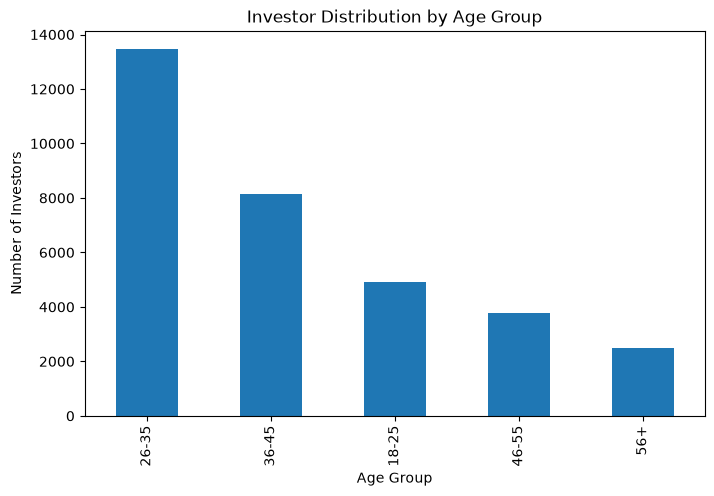

In [25]:
plt.figure(figsize=(8,5))

age_segment.plot(kind="bar")

plt.title("Investor Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Number of Investors")

plt.show()

In [26]:
transaction_segment = transactions["transaction_type"].value_counts()

transaction_segment

transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64

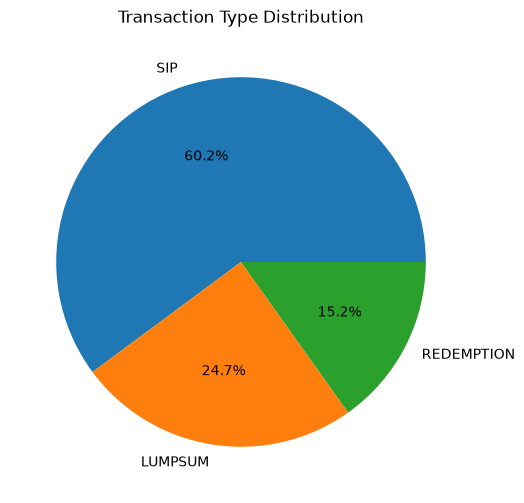

In [27]:
plt.figure(figsize=(6,6))

plt.pie(
    transaction_segment,
    labels=transaction_segment.index,
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")

plt.show()

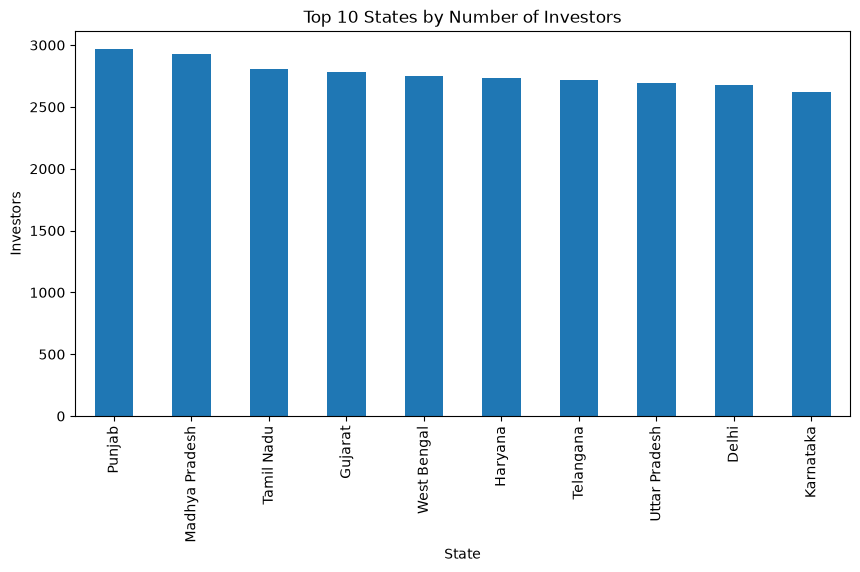

In [28]:
state_segment = transactions["state"].value_counts().head(10)

plt.figure(figsize=(10,5))

state_segment.plot(kind="bar")

plt.title("Top 10 States by Number of Investors")

plt.xlabel("State")

plt.ylabel("Investors")

plt.show()

## Investor Segmentation Insights

- The investor base is distributed across multiple age groups.
- SIP transactions form a significant share of investments.
- A few states contribute the largest number of investors.

In [29]:
recommendations = pd.read_csv(
    BASE_DIR / "data/processed/fund_recommendations.csv"
)

recommendations.head()

,amfi_code,Sharpe_Ratio,CAGR,Recommendation
0,100016,-0.201517,0.025412,High Risk
1,100025,-0.567095,0.042948,High Risk
2,100033,1.093699,0.288994,Recommended
3,101206,1.027213,0.226048,Recommended
4,101207,0.162661,0.076433,High Risk


In [30]:
recommendation_count = recommendations["Recommendation"].value_counts()

recommendation_countrecommendation_count = recommendations["Recommendation"].value_counts()

recommendation_count

Recommendation
High Risk             24
Recommended           12
Highly Recommended     4
Name: count, dtype: int64

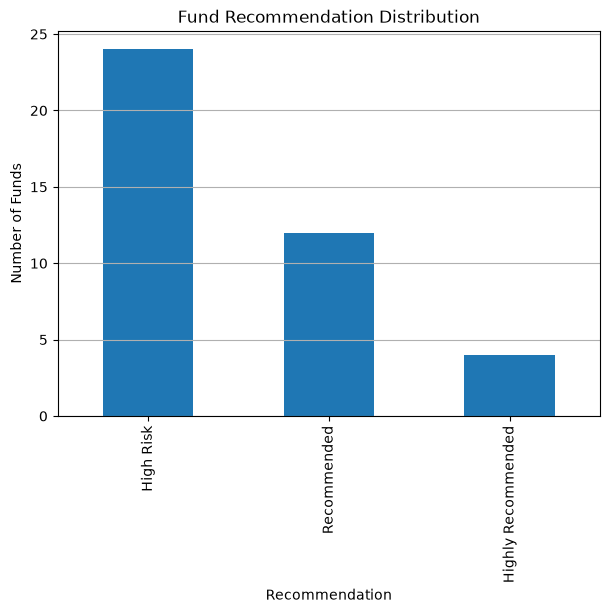

In [31]:
plt.figure(figsize=(7,5))

recommendation_count.plot(kind="bar")

plt.title("Fund Recommendation Distribution")

plt.xlabel("Recommendation")

plt.ylabel("Number of Funds")

plt.grid(axis="y")

plt.show()

In [32]:
recommended = recommendations[
    recommendations["Recommendation"] == "Highly Recommended"
]

recommended

,amfi_code,Sharpe_Ratio,CAGR,Recommendation
19,119551,1.208267,0.247726,Highly Recommended
30,120843,1.306744,0.296483,Highly Recommended
34,148567,1.448291,0.297120,Highly Recommended
36,148569,1.234930,0.306432,Highly Recommended


## Recommendation Insights

- The recommendation engine classifies funds using CAGR and Sharpe Ratio.
- Funds with higher risk-adjusted returns receive stronger recommendations.
- Investors can use these recommendations as a starting point for further analysis before investing.

In [33]:
nav.to_csv(
    BASE_DIR / "notebooks/advanced_analytics_output.csv",
    index=False
)

print("Advanced Analytics output saved successfully.")

Advanced Analytics output saved successfully.


# Conclusion

The Advanced Analytics module extends the mutual fund analysis by evaluating downside risk, return consistency, investor behaviour, and fund recommendations.

### Key Findings

- Daily returns were used to estimate Value at Risk (VaR), providing an estimate of potential downside losses.
- Rolling Volatility highlighted periods of higher and lower market risk over time.
- Rolling Sharpe Ratio measured changes in risk-adjusted performance.
- Cohort Analysis provided insights into investor activity across different investment periods.
- Investor Segmentation revealed patterns based on age group, transaction type, and geographic location.
- The recommendation engine classified funds according to their CAGR and Sharpe Ratio, helping identify stronger-performing funds.

Overall, these analyses provide a more comprehensive understanding of mutual fund performance, investment risk, and investor behaviour, supporting more informed investment decisions.